<a href="https://colab.research.google.com/github/vishal51512/CEI-internship/blob/main/week6_Vishal_Songara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.optimizers import Adam

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [3]:
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

print(x_train.shape)

(60000, 28, 28, 1)


In [4]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

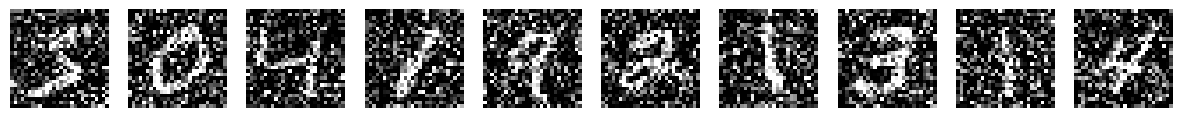

In [5]:
plt.figure(figsize=(15,3))

for i in range(10):
    ax = plt.subplot(1,10,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()

In [6]:
input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)

# Decoder

x = Conv2D(64,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),
                 activation='sigmoid',
                 padding='same')(x)

autoencoder = Model(input_img, decoded)

In [7]:
autoencoder.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = autoencoder.fit(

    x_train_noisy,
    x_train,

    epochs=10,
    batch_size=128,

    shuffle=True,

    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 214ms/step - loss: 0.1481 - val_loss: 0.1113
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 0.1076 - val_loss: 0.1034
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 0.1029 - val_loss: 0.1004
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 212ms/step - loss: 0.1006 - val_loss: 0.0992
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 221ms/step - loss: 0.0992 - val_loss: 0.0979
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 231ms/step - loss: 0.0981 - val_loss: 0.0974
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 230ms/step - loss: 0.0973 - val_loss: 0.0965
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 230ms/step - loss: 0.0967 - val_loss: 0.0960
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 230ms/step - loss: 0.0960 - val_loss: 0.0951
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 231ms/step - loss: 0.0955 - val_loss: 0.0948


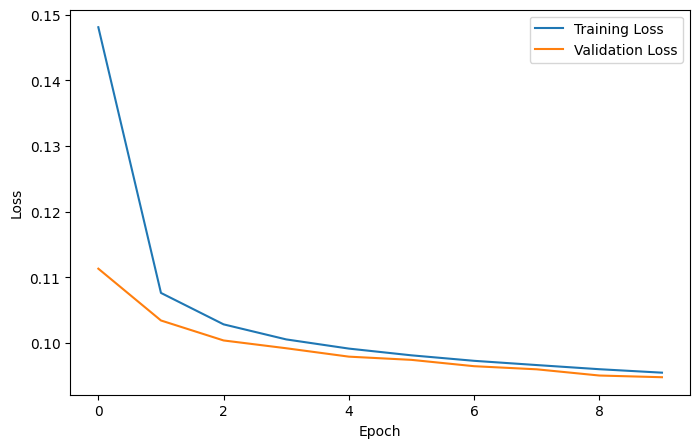

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [10]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


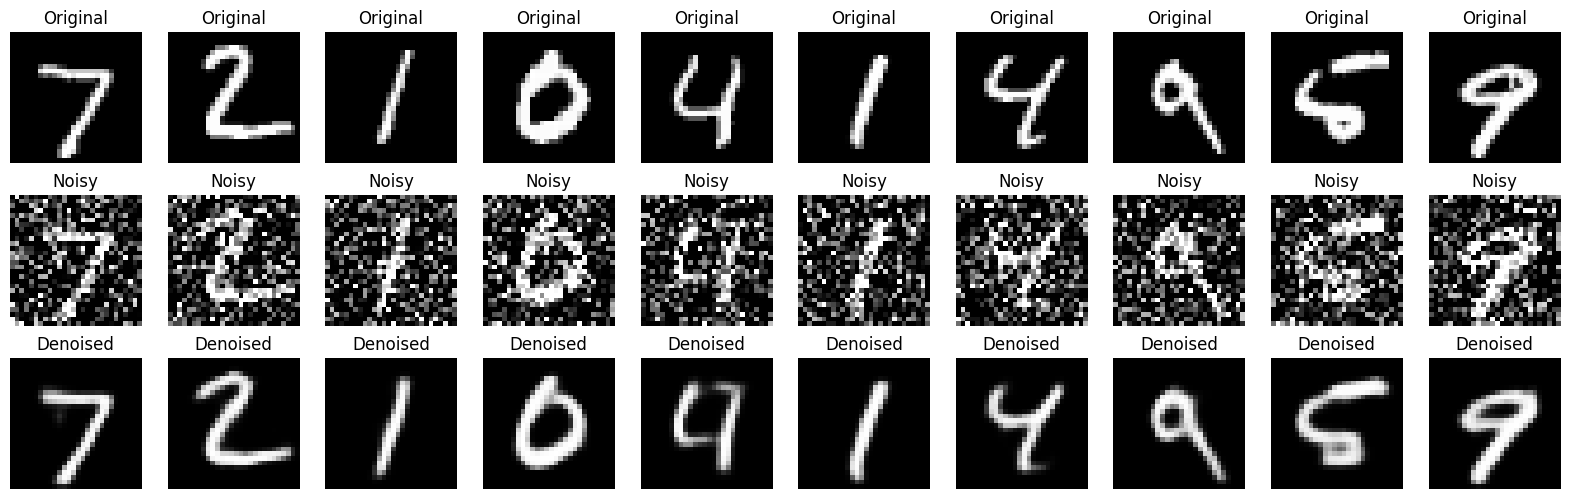

In [11]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.show()